In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv("dataset/xAPI-Edu-Data.csv")

In [3]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [4]:
df.tail()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
475,F,Jordan,Jordan,MiddleSchool,G-08,A,Chemistry,S,Father,5,4,5,8,No,Bad,Above-7,L
476,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,F,Father,50,77,14,28,No,Bad,Under-7,M
477,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,S,Father,55,74,25,29,No,Bad,Under-7,M
478,F,Jordan,Jordan,MiddleSchool,G-08,A,History,F,Father,30,17,14,57,No,Bad,Above-7,L
479,F,Jordan,Jordan,MiddleSchool,G-08,A,History,S,Father,35,14,23,62,No,Bad,Above-7,L


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [6]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [7]:
for col in df.columns:
    print(col,":",df[col].unique())
    

gender : ['M' 'F']
NationalITy : ['KW' 'lebanon' 'Egypt' 'SaudiArabia' 'USA' 'Jordan' 'venzuela' 'Iran'
 'Tunis' 'Morocco' 'Syria' 'Palestine' 'Iraq' 'Lybia']
PlaceofBirth : ['KuwaIT' 'lebanon' 'Egypt' 'SaudiArabia' 'USA' 'Jordan' 'venzuela' 'Iran'
 'Tunis' 'Morocco' 'Syria' 'Iraq' 'Palestine' 'Lybia']
StageID : ['lowerlevel' 'MiddleSchool' 'HighSchool']
GradeID : ['G-04' 'G-07' 'G-08' 'G-06' 'G-05' 'G-09' 'G-12' 'G-11' 'G-10' 'G-02']
SectionID : ['A' 'B' 'C']
Topic : ['IT' 'Math' 'Arabic' 'Science' 'English' 'Quran' 'Spanish' 'French'
 'History' 'Biology' 'Chemistry' 'Geology']
Semester : ['F' 'S']
Relation : ['Father' 'Mum']
raisedhands : [ 15  20  10  30  40  42  35  50  12  70  19   5  62  36  55  69  60   2
   0   8  25  75   4  45  14  33   7  13  29  39  49  16  28  27  21  80
  17  65  22  11   1   3 100   6  90  77  24  66  23  82  72  51  85  87
  95  81  53  92  83  67  96  57  73   9  32  52  59  61  79  18  74  97
  41  71  98  78  89  88  86  76  99  84]
VisITedResources 

In [8]:
# 1. GradeID Temizliği
df['GradeID'] = df['GradeID'].str.replace('G-', '').astype(int)

# 2. Manuel Mapping (Binary ve Ordinal)
df['gender'] = df['gender'].map({'M': 1, 'F': 0})
df['Semester'] = df['Semester'].map({'S': 1, 'F': 0})
df['Relation'] = df['Relation'].map({'Mum': 1, 'Father': 0})
df['ParentAnsweringSurvey'] = df['ParentAnsweringSurvey'].map({'Yes': 1, 'No': 0})
df['ParentschoolSatisfaction'] = df['ParentschoolSatisfaction'].map({'Good': 1, 'Bad': 0})
df['StudentAbsenceDays'] = df['StudentAbsenceDays'].map({'Above-7': 1, 'Under-7': 0})
df['SectionID'] = df['SectionID'].map({'A': 0, 'B': 1, 'C': 2})


df['StageID'] = df['StageID'].str.strip().map({'lowerlevel': 0, 'MiddleSchool': 1, 'HighSchool': 2})

# Hedef Değişken (Class)
df['Class'] = df['Class'].map({'L': 0, 'M': 1, 'H': 2})

# 3. Yeni Özellik Oluşturma 

df['is_displaced'] = (df['NationalITy'] != df['PlaceofBirth']).astype(int)


df.drop(['NationalITy', 'PlaceofBirth'], axis=1, inplace=True)

In [9]:
df = pd.get_dummies(df, columns=['Topic'], drop_first=True)

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 384 entries, 132 to 102
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   gender                    384 non-null    int64
 1   StageID                   384 non-null    int64
 2   GradeID                   384 non-null    int64
 3   SectionID                 384 non-null    int64
 4   Semester                  384 non-null    int64
 5   Relation                  384 non-null    int64
 6   raisedhands               384 non-null    int64
 7   VisITedResources          384 non-null    int64
 8   AnnouncementsView         384 non-null    int64
 9   Discussion                384 non-null    int64
 10  ParentAnsweringSurvey     384 non-null    int64
 11  ParentschoolSatisfaction  384 non-null    int64
 12  StudentAbsenceDays        384 non-null    int64
 13  is_displaced              384 non-null    int64
 14  Topic_Biology             384 non-null    boo

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


RandomForestClassifier_param = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_features": ["sqrt", "log2", None],
    "max_depth": [None, 5, 10, 20],           # Ağaçların çok fazla dallanıp ezberlemesini önlemek için
    "n_estimators": [50, 100, 150, 200, 250],
    "class_weight": ["balanced", "balanced_subsample", None] # Dengesiz sınıflar için kritik
}


rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=RandomForestClassifier_param, 
    cv=5,            
    scoring='accuracy', 
    n_jobs=-1      
)


grid_search.fit(X_train, y_train)


print("En iyi Parametreler:", grid_search.best_params_)
print("En iyi Skor (Cross-Validation):", grid_search.best_score_)


best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"Final Model Test Doğruluğu: %{accuracy_score(y_test, y_pred_final)*100:.2f}")


print("\nFinal Sınıflandırma Raporu:\n", classification_report(y_test, y_pred_final))

En iyi Parametreler: {'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 150}
En iyi Skor (Cross-Validation): 0.7892002734107997


In [ ]:

print(classification_report(y_test, y_pred_knn))
print(accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

In [21]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   -- ------------------------------------- 6.0/101.7 MB 53.0 MB/s eta 0:00:02
   -------- ------------------------------- 20.7/101.7 MB 65.3 MB/s eta 0:00:02
   ------------- -------------------------- 35.1/101.7 MB 67.7 MB/s eta 0:00:01
   -------------------- ------------------- 52.4/101.7 MB 72.8 MB/s eta 0:00:01
   --------------------------- ------------ 69.5/101.7 MB 75.2 MB/s eta 0:00:01
   ---------------------------------- ----- 88.3/101.7 MB 77.6 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 79.1 MB/s eta 0:00:01
   ---------------------------------------- 101.7/101.7 MB 74.9 MB/s  0:00:01


In [22]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# XGBoost Parametreleri
xgb_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("XGBoost En İyi Parametreler:", xgb_grid.best_params_)
print(f"XGBoost En İyi CV Skoru: %{xgb_grid.best_score_*100:.2f}")

# Test seti başarısı
xgb_final_score = xgb_grid.best_estimator_.score(X_test, y_test)
print(f"XGBoost Final Test Doğruluğu: %{xgb_final_score*100:.2f}")

XGBoost En İyi Parametreler: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
XGBoost En İyi CV Skoru: %76.82
XGBoost Final Test Doğruluğu: %83.33


C:\Users\PC\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:25:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [29]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])


svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    'svm__kernel': ['rbf', 'poly', 'sigmoid']
}

svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid=svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("SVM En İyi Parametreler:", svm_grid.best_params_)
print(f"SVM En İyi CV Skoru: %{svm_grid.best_score_*100:.2f}")

# Test seti başarısı
svm_final_score = svm_grid.best_estimator_.score(X_test, y_test)
print(f"SVM Final Test Doğruluğu: %{svm_final_score*100:.2f}")

SVM En İyi Parametreler: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
SVM En İyi CV Skoru: %75.78
SVM Final Test Doğruluğu: %82.29


In [31]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

#  Random Forest 
final_rf = RandomForestClassifier(
    class_weight='balanced_subsample', 
    criterion='gini', 
    max_depth=None, 
    max_features='sqrt', 
    n_estimators=150, 
    random_state=42
)

#  XGBoost 
final_xgb = XGBClassifier(
    colsample_bytree=0.8, 
    learning_rate=0.1, 
    max_depth=5, 
    n_estimators=50, 
    subsample=0.8, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

#  Scaling 
final_svm = make_pipeline(
    StandardScaler(), 
    SVC(C=10, gamma=0.01, kernel='rbf', probability=True, random_state=42)
)


==================== Random Forest ANALİZİ ====================
Doğruluk Oranı (Accuracy): %84.38

Sınıflandırma Raporu:
              precision    recall  f1-score   support

     Low (0)       0.89      0.96      0.93        26
  Middle (1)       0.85      0.83      0.84        48
    High (2)       0.76      0.73      0.74        22

    accuracy                           0.84        96
   macro avg       0.84      0.84      0.84        96
weighted avg       0.84      0.84      0.84        96



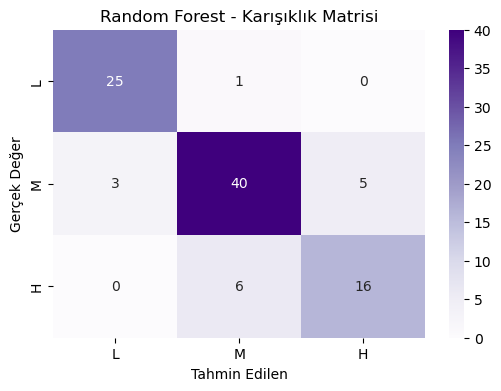


==================== XGBoost ANALİZİ ====================
Doğruluk Oranı (Accuracy): %83.33

Sınıflandırma Raporu:
              precision    recall  f1-score   support

     Low (0)       0.86      0.92      0.89        26
  Middle (1)       0.83      0.83      0.83        48
    High (2)       0.80      0.73      0.76        22

    accuracy                           0.83        96
   macro avg       0.83      0.83      0.83        96
weighted avg       0.83      0.83      0.83        96



C:\Users\PC\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:41:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


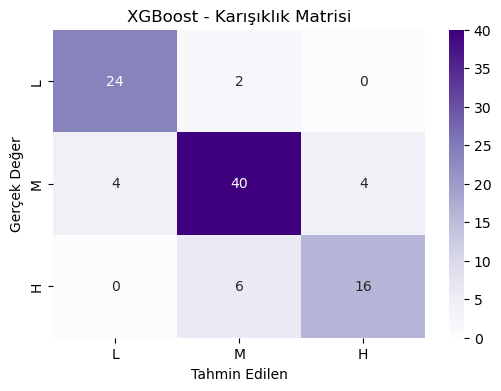


==================== SVM ANALİZİ ====================
Doğruluk Oranı (Accuracy): %82.29

Sınıflandırma Raporu:
              precision    recall  f1-score   support

     Low (0)       0.77      0.92      0.84        26
  Middle (1)       0.84      0.79      0.82        48
    High (2)       0.85      0.77      0.81        22

    accuracy                           0.82        96
   macro avg       0.82      0.83      0.82        96
weighted avg       0.83      0.82      0.82        96



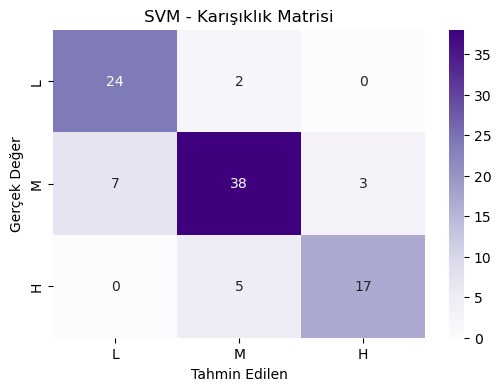

In [32]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


final_models = {
    "Random Forest": final_rf,
    "XGBoost": final_xgb,
    "SVM": final_svm
}


for name, model in final_models.items():
    print(f"\n{'='*20} {name} ANALİZİ {'='*20}")
    
    # Eğit ve Tahmin Et
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # 1. Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Doğruluk Oranı (Accuracy): %{acc*100:.2f}")
    
    # 2. Classification Report (Precision, Recall, F1)
    print("\nSınıflandırma Raporu:")
    print(classification_report(y_test, y_pred, target_names=['Low (0)', 'Middle (1)', 'High (2)']))
    
    # 3. Confusion Matrix 
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
                xticklabels=['L', 'M', 'H'], yticklabels=['L', 'M', 'H'])
    plt.title(f"{name} - Karışıklık Matrisi")
    plt.xlabel("Tahmin Edilen")
    plt.ylabel("Gerçek Değer")
    plt.show()